# Detecting Synthetic Images in AWS SageMaker

In this project I will use the CIFAKE dataset to train and deploy a Binary Classifier for detecting synthetically generated images.

## 1. Dataset preparation

We download the dataset from kaggle, unzip it, and upload it to S3 for training.

In [4]:
!curl -L -o cifake-real-and-ai-generated-synthetic-images.zip\
  https://www.kaggle.com/api/v1/datasets/download/birdy654/cifake-real-and-ai-generated-synthetic-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  104M  100  104M    0     0   101M      0  0:00:01  0:00:01 --:--:--  128M


In [ ]:
%%capture
!unzip cifake-real-and-ai-generated-synthetic-images -d cifake/

In [ ]:
!aws s3 sync cifake s3://detecting-synthetic-images-sagemaker/input_data/cifake/

We can explore a few of the images:

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

Fake image:

In [28]:
img = Image.open("./cifake/train/FAKE/1000 (10).jpg")

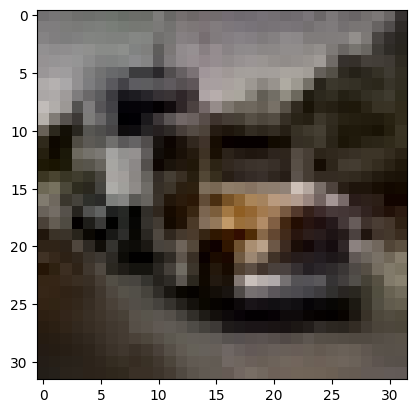

In [29]:
plt.imshow(img)

Real image:

In [30]:
img = Image.open("./cifake/train/REAL/1000 (10).jpg")

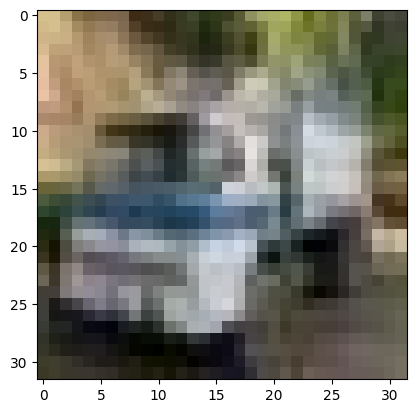

In [31]:
plt.imshow(img)

As we can see, to the naked eye, it's hard to see a difference at 32x32 resolution.

In [32]:
img.size

(32, 32)

## 2. Hyperparameter Tuning